Geoinformatik 2 – GIS-Analyse
# Übung 11: Räumliche Interpolation
Prof. Dr. Yu Feng

**Ziel dieser Übung** ist es, drei wichtige räumliche Interpolationsmethoden kennenzulernen und deren praktische Anwendung zu verstehen:

1. **IDW (Inverse Distance Weighting)** - Abstandsgewichtete Interpolation
2. **Polynominterpolation 2. Ordnung** - Flächeninterpolation durch Polynome
3. **Cubic Spline Interpolation** - Glatte Kurveninterpolation mit Stetigkeit

## Aufgabe 1: Abstandsfunktion

Das Verfahren ist auch bekannt unter dem Namen IDP (Inverse Distance to a Power). Die zu interpolierenden Höhen werden anhand des Abstandes als gewichtetes Mittel berechnet. Das
Gewicht ist invers proportional zum Abstand, der üblicherweise zur Potenz 1 oder 2 genommen
wird. Die Formel zur Bestimmung der Höhe lautet:

$$z(x,y) = \frac{\sum_{i=1}^{n} \frac{z_i}{d_i^p}}{\sum_{i=1}^{n} \frac{1}{d_i^p}}$$

wobei:
- $z(x,y)$ = Höhe des zu interpolierenden Punktes
- $z_i$ = Höhe des i-ten interpolierenden Punktes  
- $d_i$ = Abstand zum Neupunkt
- $n$ = Anzahl der betrachteten Nachbarschaft
- $p$ = Potenz (üblicherweise 2)

#### Beispieldaten erstellen

Gegeben sind folgende Punkte mit bekannten Höhenwerten:
- $P_1(1, 2)$ mit $z_1 = 5$
- $P_2(3, 4)$ mit $z_2 = 1$  
- $P_3(5, 1)$ mit $z_3 = 7$

Zu interpolieren: Neupunkt $N(3, 3)$ mit unbekanntem $z$-Wert


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Bekannte Punkte (x, y)
known_points = np.array([
    [1, 2],  # P1
    [3, 4],  # P2
    [5, 1]   # P3
])

# Zugehörige Höhenwerte z
known_values = np.array([5, 1, 7])

# Zielpunkt N(3, 3)
target_point = np.array([3, 3])

print("Bekannte Punkte:\n", known_points)
print("Z-Werte: ", known_values)
print("Zielpunkt:", target_point)


Bekannte Punkte:
 [[1 2]
 [3 4]
 [5 1]]
Z-Werte:  [5 1 7]
Zielpunkt: [3 3]


### Abstandsfunktion implementieren

**Aufgabe:** Implementieren Sie eine Funktion zur Berechnung der euklidischen Distanz zwischen zwei Punkten.

In [ ]:
def calculate_distance(point1, point2):
    """
    Berechnet die euklidische Distanz zwischen zwei Punkten.
    """
    # TODO: Implementieren Sie die euklidische Distanzformel
    # Hinweis: d = sqrt((x2-x1)^2 + (y2-y1)^2)

    # Verwenden Sie np.sqrt() und np.sum()    # return np.sqrt(np.sum((point2 - point1)**2))

    return 

In [3]:
# Berechnen der Distanzen von jedem bekannten Punkt zum Zielpunkt
distances = []
for i, point in enumerate(known_points):
    d = calculate_distance(point, target_point)
    distances.append(d)
    print(f"Distanz von P{i+1}{tuple(point)} zu N{tuple(target_point)}: {d:.4f}")

print(f"\nAlle Distanzen: {[round(d, 4) for d in distances]}")

Distanz von P1(1, 2) zu N(3, 3): 2.2361
Distanz von P2(3, 4) zu N(3, 3): 1.0000
Distanz von P3(5, 1) zu N(3, 3): 2.8284

Alle Distanzen: [2.2361, 1.0, 2.8284]


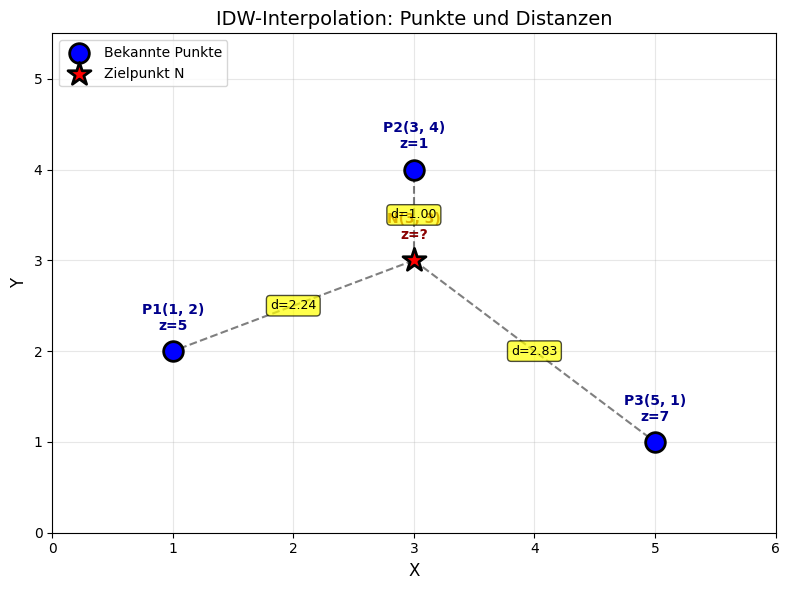

In [4]:
# Visualisierung erstellen
fig, ax = plt.subplots(figsize=(8, 6))

# Bekannte Punkte plotten (blau)
ax.scatter(known_points[:, 0], known_points[:, 1], 
           c='blue', s=200, marker='o', 
           edgecolors='black', linewidths=2,
           label='Bekannte Punkte', zorder=5)

# Bekannte Punkte beschriften
for i, (point, z) in enumerate(zip(known_points, known_values)):
    ax.text(point[0], point[1] + 0.2, 
            f'P{i+1}({point[0]}, {point[1]})\nz={z}',
            ha='center', va='bottom', fontsize=10, 
            fontweight='bold', color='darkblue')

# Zielpunkt N plotten (rot)
ax.scatter(target_point[0], target_point[1], 
           c='red', s=300, marker='*', 
           edgecolors='black', linewidths=2,
           label='Zielpunkt N', zorder=6)
ax.text(target_point[0], target_point[1] + 0.2, 
        f'N({target_point[0]}, {target_point[1]})\nz=?',
        ha='center', va='bottom', fontsize=10, 
        fontweight='bold', color='darkred')

# Linien zwischen N und bekannten Punkten zeichnen
for i, point in enumerate(known_points):
    ax.plot([target_point[0], point[0]], 
            [target_point[1], point[1]], 
            'k--', alpha=0.5, linewidth=1.5)
    
    # Distanz-Label hinzufügen
    mid_x = (target_point[0] + point[0]) / 2
    mid_y = (target_point[1] + point[1]) / 2
    ax.text(mid_x, mid_y, f'd={distances[i]:.2f}',
            ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='yellow', alpha=0.7))

# Formatierung
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('IDW-Interpolation: Punkte und Distanzen', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.set_xlim(0, 6)
ax.set_ylim(0, 5.5)

plt.tight_layout()
plt.show()

### IDW-Berechnung mit $p=2$ und $p=4$

Berechnen Sie den interpolierten Wert am Punkt $N(3,3)$ mit zwei unterschiedlichen Potenzen, um den Einfluss der Gewichtung zu vergleichen.

In [ ]:
def idw_interpolate(values, dists, power):
    """
    Implementiert Inverse Distance Weighting (IDW) Interpolation
    """
    # TODO: Implementieren Sie die IDW-Formel in 3 Schritten:
    
    # Schritt 1: Berechnen Sie die Gewichte w_i = 1/d_i^p
    # HINWEIS: Verwenden Sie np.power(dists, power) für d_i^p
    # weights = 
    
    # Schritt 2: Berechnen Sie gewichtete Summe der Werte  
    # weighted_sum = 
    
    # Schritt 3: Berechnen Sie Summe der Gewichte
    # weight_sum = 
    
    # Schritt 4: IDW-Formel = gewichtete Summe / Gewichtssumme
    return weighted_sum / weight_sum 
    

In [6]:
z_p2 = idw_interpolate(known_values, np.array(distances), power=2)
z_p4 = idw_interpolate(known_values, np.array(distances), power=4)

print(f'Interpolierter Wert bei p=2: {z_p2:.4f}')
print(f'Interpolierter Wert bei p=4: {z_p4:.4f}')

Interpolierter Wert bei p=2: 2.1698
Interpolierter Wert bei p=4: 1.2404


## Aufgabe 2: Polynominterpolation 2. Ordnung

Bei der Polynominterpolation wird eine gleitende Polynomfläche durch die gegebenen Stützpunkte gelegt. Für eine 2. Ordnung (ellipsoide Fläche) benötigt man die Gleichung:

$$z(x,y) = a_0 + a_1 x + a_2 y + a_3 xy + a_4 x^2 + a_5 y^2$$

Da 6 Parameter ($a_0$ bis $a_5$) zu bestimmen sind, benötigen wir mindestens 6 Stützpunkte.

**Beispieldaten:** Verwenden Sie folgende 6 Punkte:
- P1(1,1) z=7, P2(3,9) z=8, P3(6,3) z=3  
- P4(7,7) z=4, P5(9,0) z=9, P6(11,13) z=10

In [7]:
# Daten für Polynominterpolation
poly_points = np.array([
    [1, 1], [3, 9], [6, 3], [7, 7], [9, 0], [11, 13]
])
poly_values = np.array([7, 8, 3, 4, 9, 10])

# Zielpunkt für Interpolation
poly_target = np.array([4, 4])

print("Polynominterpolation - 6 Stützpunkte:")
for i, (p, z) in enumerate(zip(poly_points, poly_values), 1):
    print(f"P{i}({p[0]}, {p[1]}) z={z}")
print(f"\nZu interpolieren: ({poly_target[0]}, {poly_target[1]})")

Polynominterpolation - 6 Stützpunkte:
P1(1, 1) z=7
P2(3, 9) z=8
P3(6, 3) z=3
P4(7, 7) z=4
P5(9, 0) z=9
P6(11, 13) z=10

Zu interpolieren: (4, 4)


In [ ]:
# Aufstellen der Koeffizientenmatrix A für z = a0 + a1*x + a2*y + a3*xy + a4*x² + a5*y²
# Jede Zeile entspricht einem Punkt [1, x, y, xy, x², y²]

# TODO: Erstellen Sie die 6x6 Koeffizientenmatrix
# Für jeden Punkt (x,y) erstellen Sie eine Zeile: [1, x, y, x*y, x², y²]
A = np.zeros((6, 6))
for i, (x, y) in enumerate(poly_points):
    # Füllen Sie die Matrix-Zeile aus:
    # A[i] = [___, ___, ___, ___, ___, ___]


print("Koeffizientenmatrix A:")
print(A)

print("\nHöhenwerte b:")
print(poly_values)

Koeffizientenmatrix A:
[[  1.   1.   1.   1.   1.   1.]
 [  1.   3.   9.  27.   9.  81.]
 [  1.   6.   3.  18.  36.   9.]
 [  1.   7.   7.  49.  49.  49.]
 [  1.   9.   0.   0.  81.   0.]
 [  1.  11.  13. 143. 121. 169.]]

Höhenwerte b:
[ 7  8  3  4  9 10]


In [9]:
# Lösung des Gleichungssystems A * coeffs = b
coeffs = np.linalg.solve(A, poly_values)

print("Berechnete Koeffizienten [a0, a1, a2, a3, a4, a5]:")
print([f"a{i}: {coef:.6f}" for i, coef in enumerate(coeffs)])

# Interpolation am Zielpunkt (4, 4)
x, y = poly_target
z_poly = coeffs[0] + coeffs[1]*x + coeffs[2]*y + coeffs[3]*x*y + coeffs[4]*x**2 + coeffs[5]*y**2

print(f"\nPolynominterpolation bei ({x}, {y}): z = {z_poly:.4f}")

# Verifikation: Prüfung an den Stützpunkten
print("\nVerifikation an Stützpunkten:")
for i, ((x, y), z_orig) in enumerate(zip(poly_points, poly_values)):
    z_calc = coeffs[0] + coeffs[1]*x + coeffs[2]*y + coeffs[3]*x*y + coeffs[4]*x**2 + coeffs[5]*y**2
    print(f"P{i+1}: Original z={z_orig}, Berechnet z={z_calc:.4f}, Differenz={abs(z_orig-z_calc):.6f}")

Berechnete Koeffizienten [a0, a1, a2, a3, a4, a5]:
['a0: 9.005921', 'a1: -3.054605', 'a2: 0.833553', 'a3: -0.141886', 'a4: 0.339327', 'a5: 0.017690']

Polynominterpolation bei (4, 4): z = 3.5638

Verifikation an Stützpunkten:
P1: Original z=7, Berechnet z=7.0000, Differenz=0.000000
P2: Original z=8, Berechnet z=8.0000, Differenz=0.000000
P3: Original z=3, Berechnet z=3.0000, Differenz=0.000000
P4: Original z=4, Berechnet z=4.0000, Differenz=0.000000
P5: Original z=9, Berechnet z=9.0000, Differenz=0.000000
P6: Original z=10, Berechnet z=10.0000, Differenz=0.000000


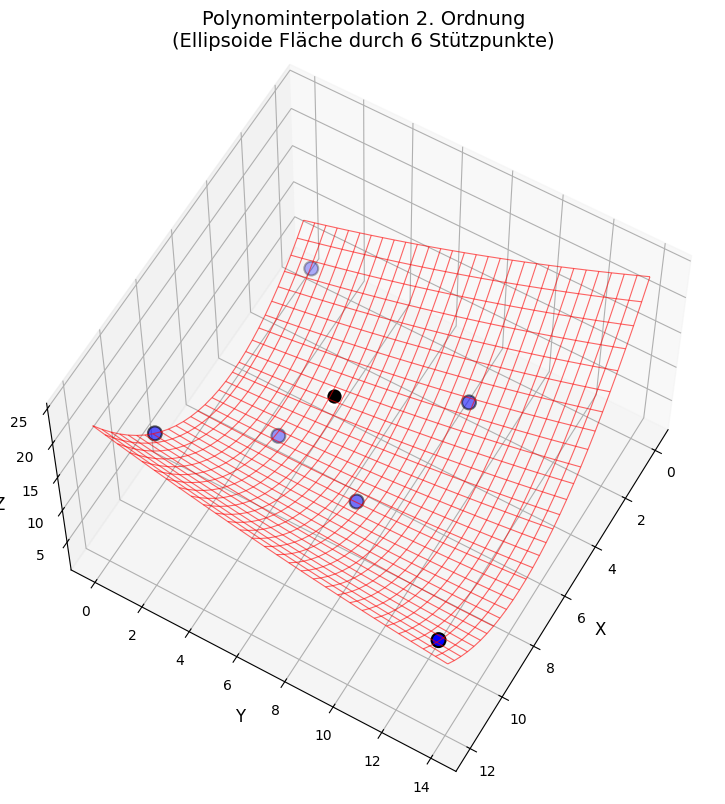

Interpolierter Punkt (4, 4) liegt auf der Fläche bei z = 3.564


In [10]:
# 3D-Visualisierung der Polynomfläche
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Erstelle Gitter für die Polynomfläche
x_range = np.linspace(0, 12, 30)
y_range = np.linspace(0, 14, 30)
X, Y = np.meshgrid(x_range, y_range)

# Berechne Z-Werte für die Polynomfläche
Z = (coeffs[0] + coeffs[1]*X + coeffs[2]*Y + 
     coeffs[3]*X*Y + coeffs[4]*X**2 + coeffs[5]*Y**2)

# Plotte die Polynomfläche als Wireframe (rot)
ax.plot_wireframe(X, Y, Z, color='red', alpha=0.6, linewidth=0.8)

# Plotte die Stützpunkte (blau)
ax.scatter(poly_points[:, 0], poly_points[:, 1], poly_values, 
           c='blue', s=100, marker='o', edgecolors='black', linewidths=1.5)

# Markiere den interpolierten Punkt (schwarz)
ax.scatter(poly_target[0], poly_target[1], z_poly, 
           c='black', s=150, marker='o', edgecolors='white', linewidths=2)

# Beschriftung
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12) 
ax.set_zlabel('Z', fontsize=12)
ax.set_title('Polynominterpolation 2. Ordnung\n(Ellipsoide Fläche durch 6 Stützpunkte)', 
             fontsize=14, pad=20)

# Ansichtswinkel anpassen (von oben schauen)
ax.view_init(elev=60, azim=30)

plt.tight_layout()
plt.show()

print(f"Interpolierter Punkt ({poly_target[0]}, {poly_target[1]}) liegt auf der Fläche bei z = {z_poly:.3f}")

## Aufgabe 3: Cubic Spline Interpolation

Splines sind zusammengesetzte kubische Polynome, die durch eine bestimmte Anzahl von Punkten verlaufen und dabei eine glatte Verbindung an den Stützstellen gewährleisten.

**Spline-Formel**: $S_i(x) = a_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3$

### Stetigkeit auf einen Blick:

| Typ | Bedingung | Bedeutung | Formel |
|-----|-----------|-----------|--------|
| **C⁰** | Funktionswerte | Keine Sprünge | $S_i(x_{i+1}) = S_{i+1}(x_{i+1})$ |
| **C¹** | 1. Ableitung | Keine Knicke | $S'_i(x_{i+1}) = S'_{i+1}(x_{i+1})$ |
| **C²** | 2. Ableitung | Glatte Krümmung | $S''_i(x_{i+1}) = S''_{i+1}(x_{i+1})$ |

**Daten**: P1(0,1), P2(1,3), P3(2,2), P4(3,4), P5(4,1)

In [11]:
# Daten für Cubic Spline Konstruktion
spline_x = np.array([0, 1, 2, 3, 4])
spline_y = np.array([1, 3, 2, 4, 1])
n = len(spline_x)

print("CUBIC SPLINE KONSTRUKTION")
print("=" * 40)
print("Stützpunkte:")
for i, (x, y) in enumerate(zip(spline_x, spline_y)):
    print(f"  P{i+1}({x}, {y})")

# Intervallbreiten berechnen
h = np.diff(spline_x)  # h[i] = x[i+1] - x[i]
print(f"\nIntervallbreiten h: {h}")
print()

# System-Parameter definieren
num_intervals = n - 1  # Intervalle
num_coeffs = 4 * num_intervals  # Koeffizienten total

print(f"Anzahl Intervalle: {num_intervals}")
print(f"Koeffizienten pro Intervall: 4 [a_i, b_i, c_i, d_i]")
print(f"Gesamtzahl Unbekannte: {num_coeffs}")
print()

CUBIC SPLINE KONSTRUKTION
Stützpunkte:
  P1(0, 1)
  P2(1, 3)
  P3(2, 2)
  P4(3, 4)
  P5(4, 1)

Intervallbreiten h: [1 1 1 1]

Anzahl Intervalle: 4
Koeffizienten pro Intervall: 4 [a_i, b_i, c_i, d_i]
Gesamtzahl Unbekannte: 16



SCHRITTWEISE KONSTRUKTION DER 16×16 CUBIC SPLINE MATRIX
Wir werden die Matrix Schritt für Schritt aufbauen:
1. Interpolationsbedingungen (8 Zeilen)
2. C¹-Stetigkeitsbedingungen (3 Zeilen)
3. C²-Stetigkeitsbedingungen (3 Zeilen)
4. Randbedingungen (2 Zeilen)


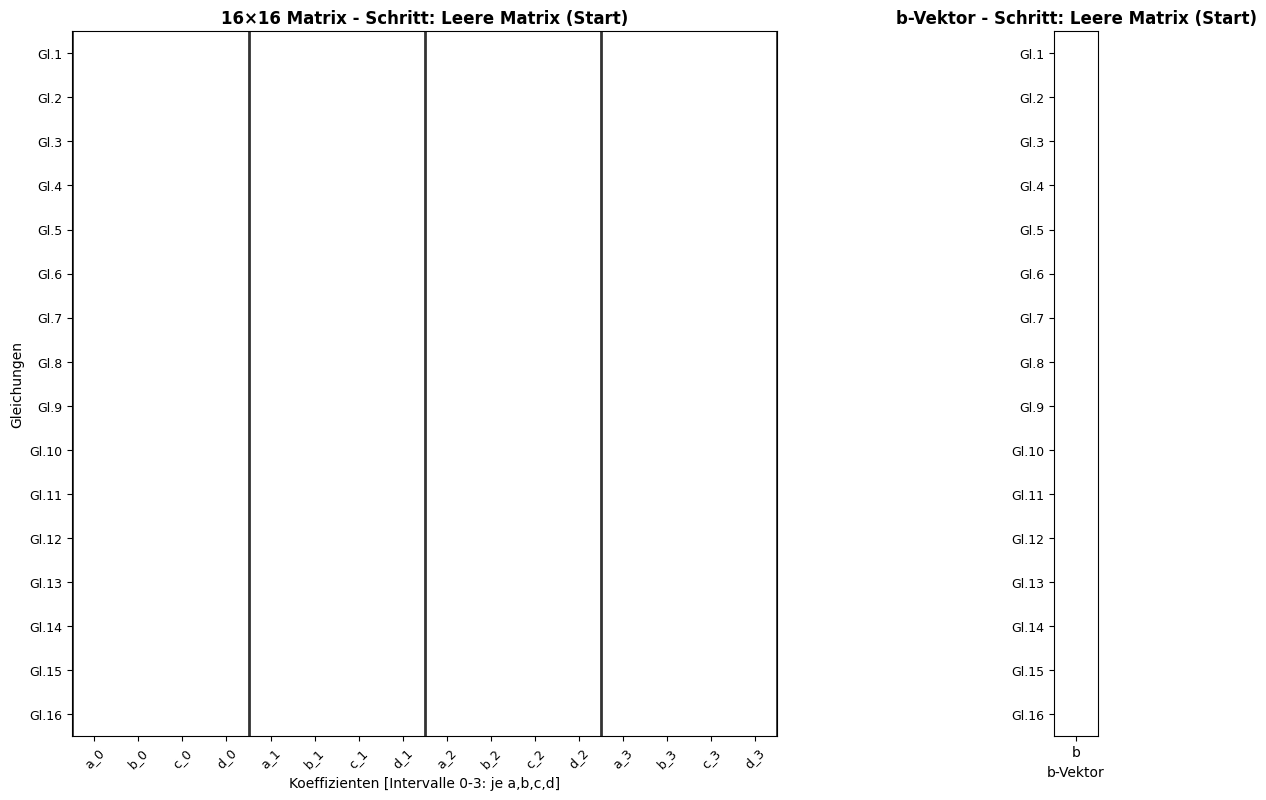

Matrix-Status nach 'Leere Matrix (Start)':
  - Gefüllte Zeilen: 0/16
--------------------------------------------------


In [12]:
# STEP-BY-STEP MATRIX CONSTRUCTION VISUALIZATION
def visualize_matrix_step(A_matrix, b_vector, step_name, constraint_rows=None):
    """
    Visualisiert die Matrix in einem bestimmten Konstruktionsschritt
    
    Parameters:
    - A_matrix: Aktuelle 16x16 Matrix
    - b_vector: Aktueller b-Vektor
    - step_name: Name des Schrittes (z.B. "Interpolation")
    - constraint_rows: Liste der Zeilen, die in diesem Schritt hinzugefügt wurden
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Matrix-Visualisierung
    # Farbkodierung: 0=weiß, nicht-null=verschiedene Farben je nach Wert
    color_matrix = np.abs(A_matrix.copy())  # Absolute Werte für Farbkodierung
    color_matrix[color_matrix > 0] = 1  # Alle nicht-null Werte werden zu 1
    
    # Spezielle Hervorhebung der aktuellen Constraint-Zeilen
    if constraint_rows:
        for row in constraint_rows:
            color_matrix[row, :] = 2  # Besondere Farbe für neue Zeilen
    
    # Benutzerdefinierte Farbkarte
    colors = ['white', 'lightblue', 'red']  # weiß=leer, blau=gefüllt, rot=neu hinzugefügt
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(colors)
    
    # Matrix anzeigen
    im1 = ax1.imshow(color_matrix, cmap=cmap, aspect='equal', vmin=0, vmax=2)
    
    # Numerische Werte in der Matrix anzeigen
    for i in range(16):
        for j in range(16):
            if abs(A_matrix[i, j]) > 1e-10:
                value = A_matrix[i, j]
                text_color = 'white' if (constraint_rows and i in constraint_rows) else 'black'
                ax1.text(j, i, f'{value:.1f}', ha='center', va='center', 
                        fontsize=8, color=text_color, fontweight='bold')
    
    # Achsenbeschriftungen für Matrix
    interval_labels = []
    for i in range(4):
        interval_labels.extend([f'a_{i}', f'b_{i}', f'c_{i}', f'd_{i}'])
    
    ax1.set_xticks(range(16))
    ax1.set_xticklabels(interval_labels, rotation=45, fontsize=9)
    ax1.set_xlabel('Koeffizienten [Intervalle 0-3: je a,b,c,d]', fontsize=10)
    
    ax1.set_yticks(range(16))
    ax1.set_yticklabels([f'Gl.{i+1}' for i in range(16)], fontsize=9)
    ax1.set_ylabel('Gleichungen', fontsize=10)
    ax1.set_title(f'16×16 Matrix - Schritt: {step_name}', fontsize=12, fontweight='bold')
    
    # Gitterlinien zur Trennung verschiedener Intervalle
    for i in range(0, 17, 4):
        ax1.axvline(x=i-0.5, color='black', linewidth=2, alpha=0.8)
    
    # b-Vektor Visualisierung als Matrix-ähnliche Spalte
    # Erstelle Farbmatrix für b-Vektor (16x1 Matrix)
    b_color_matrix = np.zeros((16, 1))
    for i in range(16):
        # Prüfe, ob diese Zeile eine Gleichung enthält
        has_equation = np.any(np.abs(A_matrix[i, :]) > 1e-10)
        
        if has_equation:
            if constraint_rows and i in constraint_rows:
                b_color_matrix[i, 0] = 2  # Rot für neue Zeilen
            else:
                b_color_matrix[i, 0] = 1  # Blau für bestehende Gleichungen
        # else bleibt 0 (weiß) für leere Zeilen
    
    # Zeige b-Vektor als 16x1 Matrix
    im2 = ax2.imshow(b_color_matrix, cmap=cmap, aspect='equal', vmin=0, vmax=2)
    
    # Numerische Werte in der b-Vektor-Matrix anzeigen
    for i in range(16):
        value = b_vector[i]
        # Prüfe, ob diese Zeile eine Gleichung enthält (Matrix-Zeile ist nicht leer)
        has_equation = np.any(np.abs(A_matrix[i, :]) > 1e-10)
        
        if has_equation:  # Alle Gleichungen anzeigen, nicht nur neue
            # Bestimme Textfarbe: weiß für neue Zeilen (rot markiert), schwarz für bestehende
            text_color = 'white' if (constraint_rows and i in constraint_rows) else 'black'
            
            if abs(value) > 1e-10:
                # Nicht-Null Werte anzeigen
                ax2.text(0, i, f'{value:.1f}', ha='center', va='center', 
                        fontsize=9, color=text_color, fontweight='bold')
            else:
                # Null Werte anzeigen (für alle Gleichungen mit b=0)
                ax2.text(0, i, '0.0', ha='center', va='center', 
                        fontsize=9, color=text_color, fontweight='bold')
    
    ax2.set_xticks([0])
    ax2.set_xticklabels(['b'], fontsize=10)
    ax2.set_xlabel('b-Vektor', fontsize=10)
    ax2.set_yticks(range(16))
    ax2.set_yticklabels([f'Gl.{i+1}' for i in range(16)], fontsize=9)
    ax2.set_title(f'b-Vektor - Schritt: {step_name}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Statistik ausgeben
    non_zero_count = np.count_nonzero(A_matrix > 1e-10)
    filled_rows = np.count_nonzero(np.any(A_matrix > 1e-10, axis=1))
    print(f"Matrix-Status nach '{step_name}':")
    print(f"  - Gefüllte Zeilen: {filled_rows}/16")
    if constraint_rows:
        print(f"  - Neu hinzugefügte Zeilen: {constraint_rows}")
    print("-" * 50)

# Initialisierung für schrittweise Konstruktion
A_step = np.zeros((num_coeffs, num_coeffs))  # Leere Matrix zum schrittweisen Füllen
b_step = np.zeros(num_coeffs)        # Leerer b-Vektor

print("SCHRITTWEISE KONSTRUKTION DER 16×16 CUBIC SPLINE MATRIX")
print("=" * 60)
print("Wir werden die Matrix Schritt für Schritt aufbauen:")
print("1. Interpolationsbedingungen (8 Zeilen)")
print("2. C¹-Stetigkeitsbedingungen (3 Zeilen)")  
print("3. C²-Stetigkeitsbedingungen (3 Zeilen)")
print("4. Randbedingungen (2 Zeilen)")
print("=" * 60)

# Schritt 0: Leere Matrix anzeigen
visualize_matrix_step(A_step, b_step, "Leere Matrix (Start)", [])

### C⁰-Interpolationsbedingungen (Funktionswerte)

**Ziel**: Der Spline muss durch alle Stützpunkte verlaufen → keine Sprünge

**Bedingung**: $S_i(x_i) = y_i$ und $S_i(x_{i+1}) = y_{i+1}$ für alle Intervalle

#### Mathematische Grundlage:
Für jedes Intervall $[x_i, x_{i+1}]$ mit Spline $S_i(x) = a_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3$

**Interpolationsbedingungen:**
1. **Am linken Ende**: $S_i(x_i) = y_i$ → $a_i = y_i$ (da alle anderen Terme = 0)
2. **Am rechten Ende**: $S_i(x_{i+1}) = y_{i+1}$ → $a_i + b_i h_i + c_i h_i^2 + d_i h_i^3 = y_{i+1}$

**Ergebnis**: 8 Gleichungen für 4 Intervalle (je 2 pro Intervall)

Hinzufügen der Interpolationsbedingungen:
  Gl.1: S_0(0) = 1 --> a_0 = 1
  Gl.2: S_0(1) = 3 --> a_0 + b_0·1 + c_0·1 + d_0·1 = 3
  Gl.3: S_1(1) = 3 --> a_1 = 3
  Gl.4: S_1(2) = 2 --> a_1 + b_1·1 + c_1·1 + d_1·1 = 2
  Gl.5: S_2(2) = 2 --> a_2 = 2
  Gl.6: S_2(3) = 4 --> a_2 + b_2·1 + c_2·1 + d_2·1 = 4
  Gl.7: S_3(3) = 4 --> a_3 = 4
  Gl.8: S_3(4) = 1 --> a_3 + b_3·1 + c_3·1 + d_3·1 = 1

Insgesamt 8 Interpolationsbedingungen hinzugefügt.


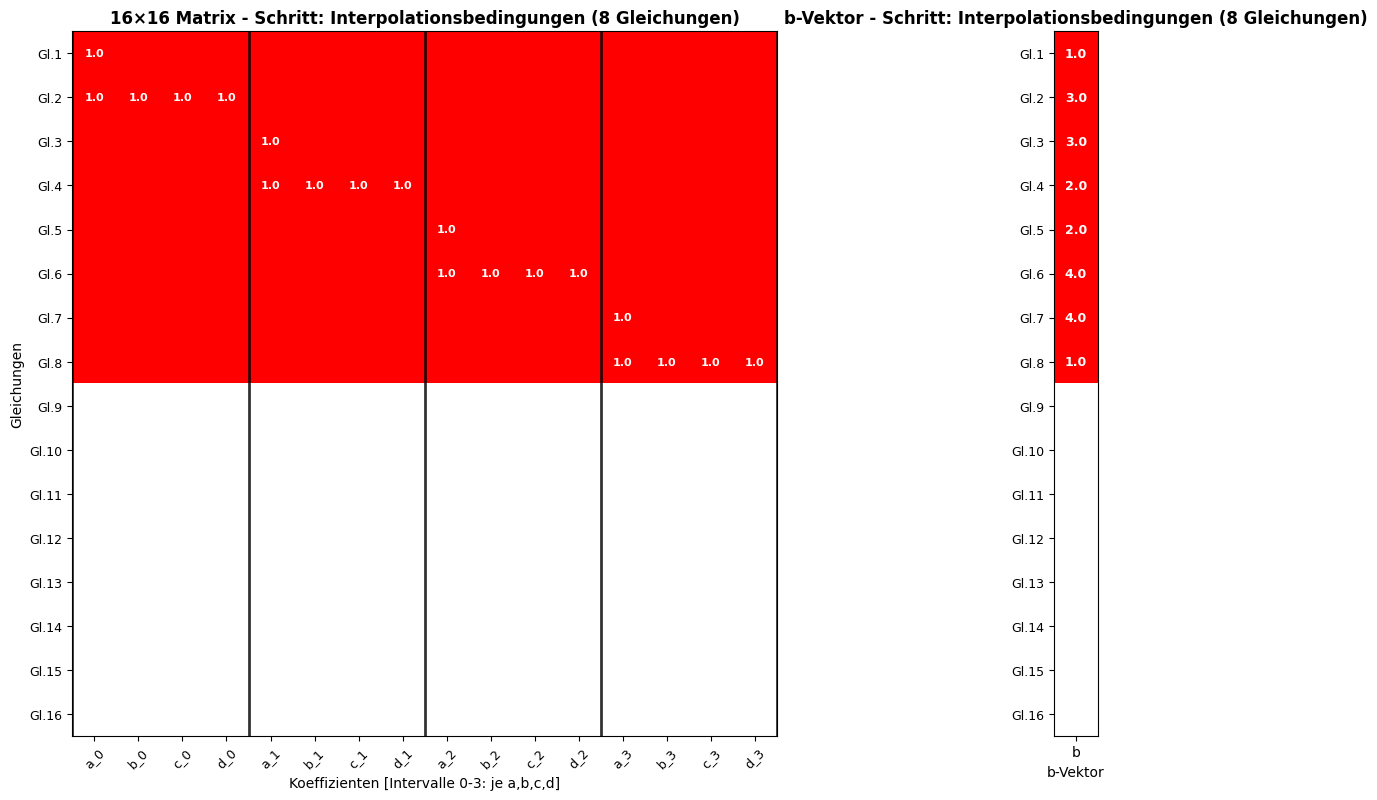

Matrix-Status nach 'Interpolationsbedingungen (8 Gleichungen)':
  - Gefüllte Zeilen: 8/16
  - Neu hinzugefügte Zeilen: [0, 1, 2, 3, 4, 5, 6, 7]
--------------------------------------------------


In [ ]:
# SCHRITT 1: INTERPOLATIONSBEDINGUNGEN HINZUFÜGEN
equation_count = 0
interpolation_rows = []

print("Hinzufügen der Interpolationsbedingungen:")
# Für jeden Intervall: S_i(x_i) = y_i und S_i(x_{i+1}) = y_{i+1}
for i in range(4):  # 4 Intervalle
    # TODO: Implementieren Sie die C⁰-Interpolationsbedingungen
    
    # Bedingung 1: S_i(x_i) = y_i  -->  a_i = y_i
    
    # Füllen Sie die Koeffizienten aus:
    # A_step[equation_count, 4*i] = ___      # Koeffizient für a_i
    # b_step[equation_count] = ___           # Rechte Seite = y_i
    
    interpolation_rows.append(equation_count)
    print(f"  Gl.{equation_count+1}: S_{i}({spline_x[i]}) = {spline_y[i]} --> a_{i} = {spline_y[i]}")
    equation_count += 1
    
    # Bedingung 2: S_i(x_{i+1}) = y_{i+1}  
    # S_i(x_{i+1}) = a_i + b_i*h_i + c_i*h_i² + d_i*h_i³ = y_{i+1}
    
    # Füllen Sie die Koeffizienten aus:
    # A_step[equation_count, 4*i] = ___      # Koeffizient für a_i
    # A_step[equation_count, 4*i+1] = ___    # Koeffizient für b_i * h_i
    # A_step[equation_count, 4*i+2] = ___    # Koeffizient für c_i * h_i²
    # A_step[equation_count, 4*i+3] = ___    # Koeffizient für d_i * h_i³
    # b_step[equation_count] = ___           # Rechte Seite = y_{i+1}
    
    interpolation_rows.append(equation_count)
    print(f"  Gl.{equation_count+1}: S_{i}({spline_x[i+1]}) = {spline_y[i+1]} --> a_{i} + b_{i}·{h[i]} + c_{i}·{h[i]**2} + d_{i}·{h[i]**3} = {spline_y[i+1]}")
    equation_count += 1

print(f"\nInsgesamt {len(interpolation_rows)} Interpolationsbedingungen hinzugefügt.")

# Visualisierung nach Schritt 1
visualize_matrix_step(A_step, b_step, "Interpolationsbedingungen (8 Gleichungen)", interpolation_rows)

### C¹-Stetigkeitsbedingungen (Erste Ableitung)

**Ziel**: Die erste Ableitung muss an den inneren Knoten stetig sein → keine Knicke

**Bedingung**: $S'_i(x_{i+1}) = S'_{i+1}(x_{i+1})$ für $i = 0, 1, 2$

#### Mathematische Herleitung:
Gegeben: $S_i(x) = a_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3$

**Erste Ableitung**: $S'_i(x) = b_i + 2c_i(x-x_i) + 3d_i(x-x_i)^2$

**An Knoten** $x_{i+1}$:
- **Links**: $S'_i(x_{i+1}) = b_i + 2c_i \cdot h_i + 3d_i \cdot h_i^2$  
- **Rechts**: $S'_{i+1}(x_{i+1}) = b_{i+1}$

**Gleichung**: $b_i + 2c_i \cdot h_i + 3d_i \cdot h_i^2 = b_{i+1}$

**Matrix-Form**: $b_i + 2c_i \cdot h_i + 3d_i \cdot h_i^2 - b_{i+1} = 0$

Hinzufügen der C¹-Stetigkeitsbedingungen (erste Ableitung stetig):
  Gl.9: S'_0(1) = S'_1(1)
           --> b_0 + 2·c_0·1 + 3·d_0·1 = b_1
  Gl.10: S'_1(2) = S'_2(2)
           --> b_1 + 2·c_1·1 + 3·d_1·1 = b_2
  Gl.11: S'_2(3) = S'_3(3)
           --> b_2 + 2·c_2·1 + 3·d_2·1 = b_3

Insgesamt 3 C¹-Stetigkeitsbedingungen hinzugefügt.


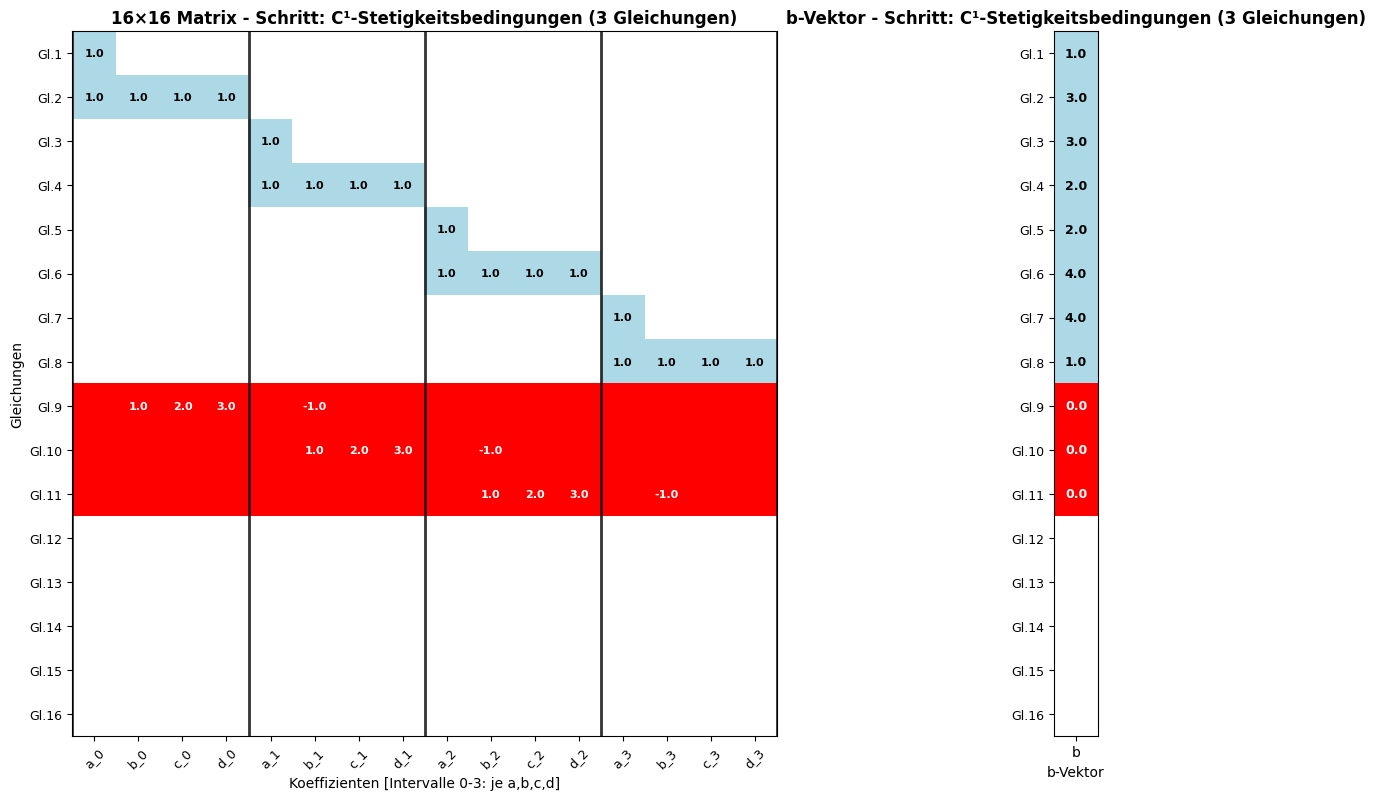

Matrix-Status nach 'C¹-Stetigkeitsbedingungen (3 Gleichungen)':
  - Gefüllte Zeilen: 11/16
  - Neu hinzugefügte Zeilen: [8, 9, 10]
--------------------------------------------------


In [ ]:
# SCHRITT 2: C¹-STETIGKEITSBEDINGUNGEN HINZUFÜGEN
c1_rows = []
print("Hinzufügen der C¹-Stetigkeitsbedingungen (erste Ableitung stetig):")

for i in range(3):  # 3 innere Knoten
    # TODO: Implementieren Sie die C¹-Stetigkeitsbedingungen
    # Mathematische Gleichung: b_i + 2c_i·h_i + 3d_i·h_i² - b_{i+1} = 0
    
    # Implementieren Sie die C¹-Bedingung:
    # A_step[equation_count, 4*i+1] = ___        # Koeffizient für b_i
    # A_step[equation_count, 4*i+2] = ___        # Koeffizient für c_i 
    # A_step[equation_count, 4*i+3] = ___        # Koeffizient für d_i 
    # A_step[equation_count, 4*(i+1)+1] = ___    # Koeffizient für b_{i+1}
    # b_step[equation_count] = ___               # Rechte Seite
    
    c1_rows.append(equation_count)
    print(f"  Gl.{equation_count+1}: S'_{i}({spline_x[i+1]}) = S'_{i+1}({spline_x[i+1]})")
    print(f"           --> b_{i} + 2·c_{i}·{h[i]} + 3·d_{i}·{h[i]**2} = b_{i+1}")
    equation_count += 1

print(f"\nInsgesamt {len(c1_rows)} C¹-Stetigkeitsbedingungen hinzugefügt.")

# Visualisierung nach Schritt 2
visualize_matrix_step(A_step, b_step, "C¹-Stetigkeitsbedingungen (3 Gleichungen)", c1_rows)

### C²-Stetigkeitsbedingungen (Zweite Ableitung)

**Ziel**: Die zweite Ableitung muss an den inneren Knoten stetig sein → glatte Krümmung

**Bedingung**: $S''_i(x_{i+1}) = S''_{i+1}(x_{i+1})$ für $i = 0, 1, 2$

#### Mathematische Herleitung:
**Zweite Ableitung**: $S''_i(x) = 2c_i + 6d_i(x-x_i)$

**An Knoten** $x_{i+1}$:
- **Links**: $S''_i(x_{i+1}) = 2c_i + 6d_i \cdot h_i$  
- **Rechts**: $S''_{i+1}(x_{i+1}) = 2c_{i+1}$

**Gleichung**: $2c_i + 6d_i \cdot h_i = 2c_{i+1}$

**Matrix-Form**: $2c_i + 6d_i \cdot h_i - 2c_{i+1} = 0$

Hinzufügen der C²-Stetigkeitsbedingungen (zweite Ableitung stetig):
  Gl.12: S''_0(1) = S''_1(1)
           --> 2·c_0 + 6·d_0·1 = 2·c_1
  Gl.13: S''_1(2) = S''_2(2)
           --> 2·c_1 + 6·d_1·1 = 2·c_2
  Gl.14: S''_2(3) = S''_3(3)
           --> 2·c_2 + 6·d_2·1 = 2·c_3

Insgesamt 3 C²-Stetigkeitsbedingungen hinzugefügt.


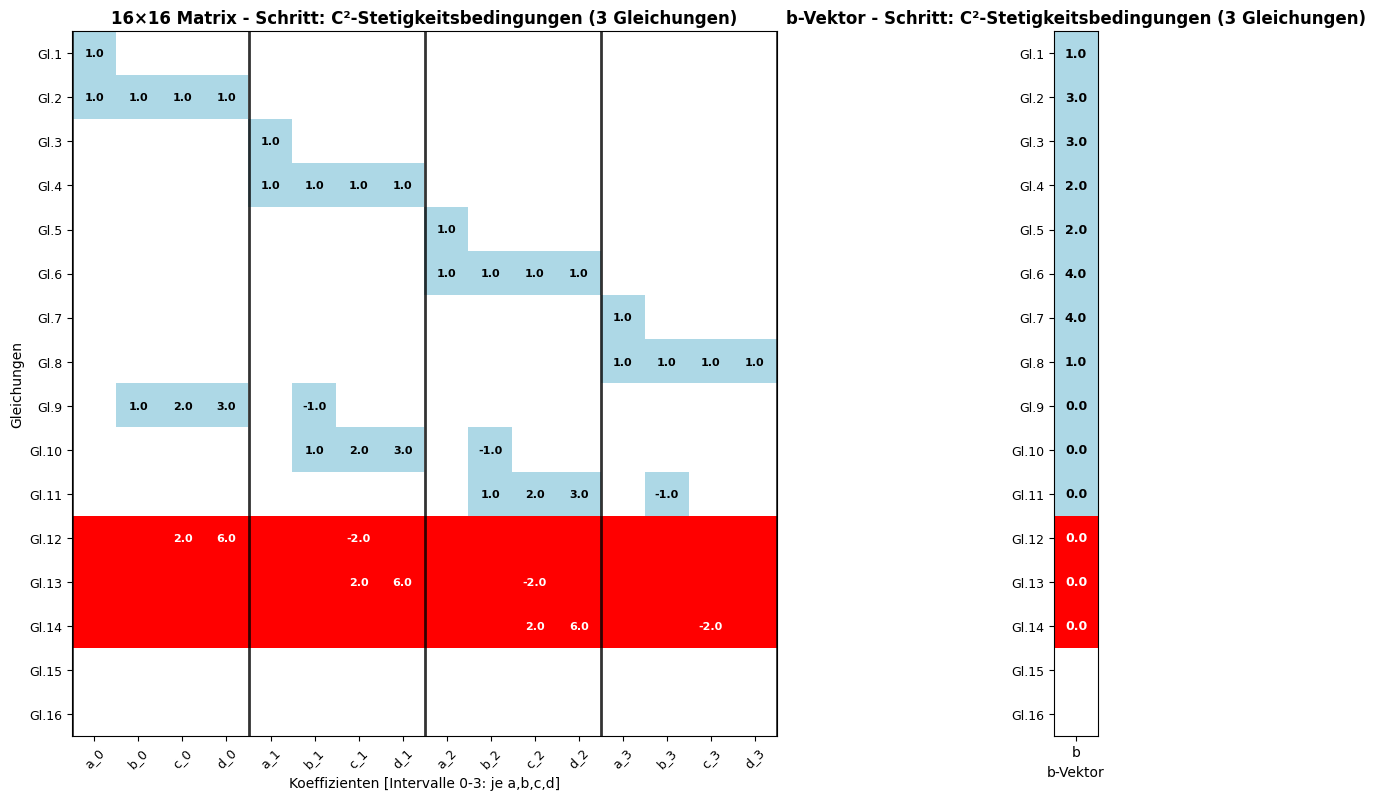

Matrix-Status nach 'C²-Stetigkeitsbedingungen (3 Gleichungen)':
  - Gefüllte Zeilen: 14/16
  - Neu hinzugefügte Zeilen: [11, 12, 13]
--------------------------------------------------


In [ ]:
# SCHRITT 3: C²-STETIGKEITSBEDINGUNGEN HINZUFÜGEN
c2_rows = []
print("Hinzufügen der C²-Stetigkeitsbedingungen (zweite Ableitung stetig):")

for i in range(3):  # 3 innere Knoten
    # TODO: Implementieren Sie die C²-Stetigkeitsbedingungen
    # Mathematische Gleichung: 2c_i + 6d_i·h_i - 2c_{i+1} = 0
    
    # Implementieren Sie die C²-Bedingung:
    # A_step[equation_count, 4*i+2] = ___        # Koeffizient für c_i 
    # A_step[equation_count, 4*i+3] = ___        # Koeffizient für d_i 
    # A_step[equation_count, 4*(i+1)+2] = ___    # Koeffizient für c_{i+1} 
    # b_step[equation_count] = ___               # Rechte Seite 
    
    c2_rows.append(equation_count)
    print(f"  Gl.{equation_count+1}: S''_{i}({spline_x[i+1]}) = S''_{i+1}({spline_x[i+1]})")
    print(f"           --> 2·c_{i} + 6·d_{i}·{h[i]} = 2·c_{i+1}")
    equation_count += 1

print(f"\nInsgesamt {len(c2_rows)} C²-Stetigkeitsbedingungen hinzugefügt.")

# Visualisierung nach Schritt 3
visualize_matrix_step(A_step, b_step, "C²-Stetigkeitsbedingungen (3 Gleichungen)", c2_rows)

### Natürliche Randbedingungen (Natural Boundary Conditions)

**Ziel**: Die beiden fehlenden Gleichungen durch Randbedingungen vervollständigen

**Bedingung**: $S''(x_0) = 0$ und $S''(x_n) = 0$ → natürlicher Spline

#### Mathematische Herleitung:

**Warum "natürliche" Randbedingungen?**
Ein natürlicher Spline minimiert die Krümmungsenergie und wird an den Enden nicht "gezwungen" → die zweite Ableitung ist Null.

**Randbedingungen für unser System:**

1. **Linker Rand**: $S''_0(x_0) = 0$ → $2c_0 + 6d_0 \cdot 0 = 2c_0 = 0$
2. **Rechter Rand**: $S''_3(x_4) = 0$ → $2c_3 + 6d_3 \cdot h_3 = 0$

**Ergebnis**: 2 weitere Gleichungen → System ist vollständig bestimmt (16 Gleichungen für 16 Unbekannte)

Hinzufügen der natürlichen Randbedingungen (zweite Ableitung = 0 an den Enden):

 RANDBEDINGUNG 1: Linker Rand S''_0(x_0) = 0
  Gl.15: S''_0(0) = 0 → 2c_0 = 0
           Matrix: A[14, 2] = 2, b[14] = 0

 RANDBEDINGUNG 2: Rechter Rand S''_3(x_4) = 0
  Gl.16: S''_3(4) = 0 → 2c_3 + 6d_3·1 = 0
           Matrix: A[15, 14] = 2, A[15, 15] = 6.0, b[15] = 0

 SYSTEM-STATUS:
   - Interpolationsbedingungen: 8 Gleichungen (C⁰-Stetigkeit)
   - C¹-Stetigkeitsbedingungen: 3 Gleichungen (erste Ableitung stetig)
   - C²-Stetigkeitsbedingungen: 3 Gleichungen (zweite Ableitung stetig)
   - Natürliche Randbedingungen: 2 Gleichungen (S''=0 an Rändern)
   - GESAMT: 16 Gleichungen für 16 Unbekannte

 Das System ist vollständig bestimmt und bereit zur Lösung!


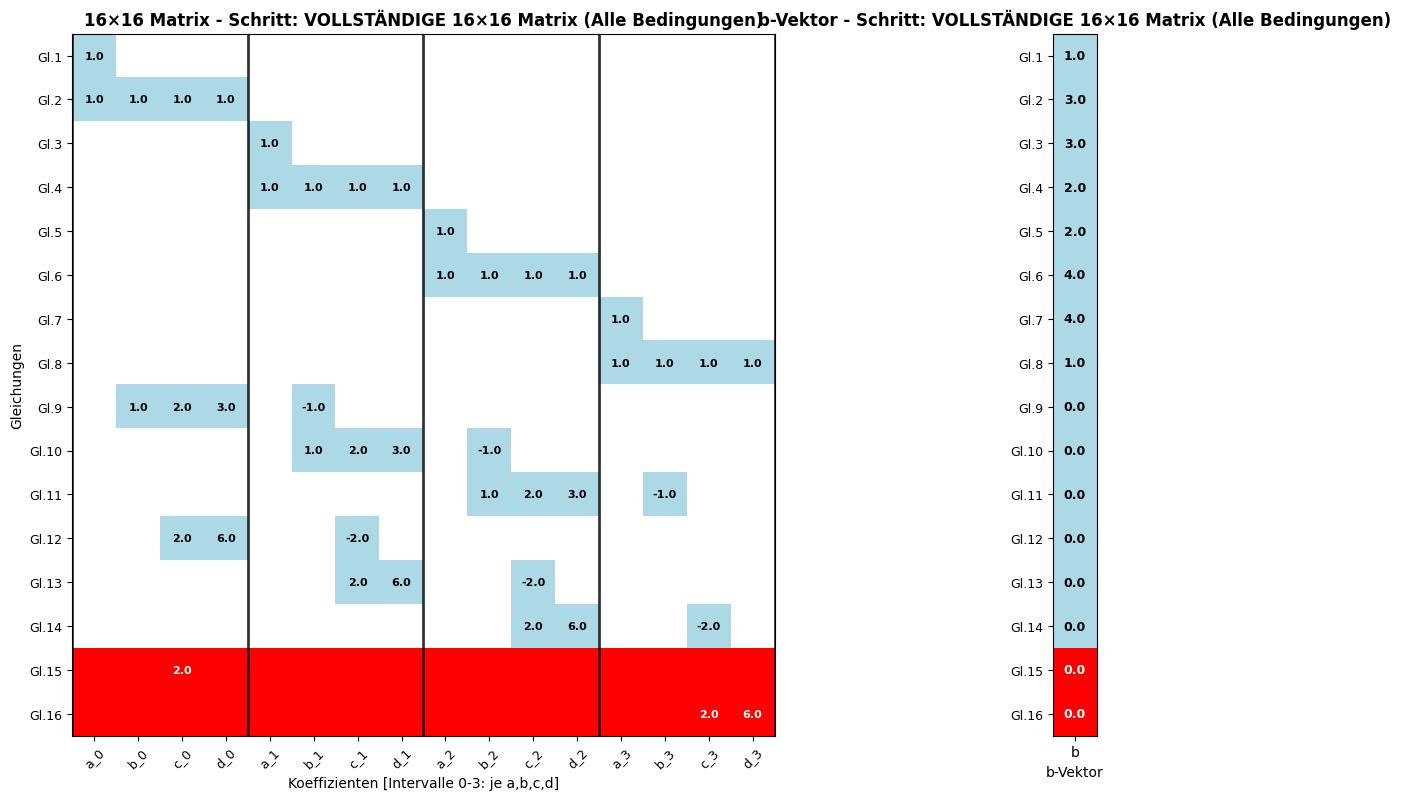

Matrix-Status nach 'VOLLSTÄNDIGE 16×16 Matrix (Alle Bedingungen)':
  - Gefüllte Zeilen: 16/16
  - Neu hinzugefügte Zeilen: [14, 15]
--------------------------------------------------


In [ ]:
# SCHRITT 4: NATÜRLICHE RANDBEDINGUNGEN HINZUFÜGEN
boundary_rows = []
print("Hinzufügen der natürlichen Randbedingungen (zweite Ableitung = 0 an den Enden):")

# TODO: Implementieren Sie die natürlichen Randbedingungen

print("\n RANDBEDINGUNG 1: Linker Rand S''_0(x_0) = 0")
# Implementieren Sie die erste Randbedingung:
# A_step[equation_count, 4*0+2] = ___     # Koeffizient für c_0
# b_step[equation_count] = ___            # Rechte Seite

boundary_rows.append(equation_count)
print(f"  Gl.{equation_count+1}: S''_0({spline_x[0]}) = 0 → 2c_0 = 0")
print(f"           Matrix: A[{equation_count}, {4*0+2}] = 2, b[{equation_count}] = 0")
equation_count += 1

print("\n RANDBEDINGUNG 2: Rechter Rand S''_3(x_4) = 0")
# Implementieren Sie die zweite Randbedingung:
# A_step[equation_count, 4*3+2] = ___     # Koeffizient für c_3
# A_step[equation_count, 4*3+3] = ___     # Koeffizient für d_3*h_3
# b_step[equation_count] = ___            # Rechte Seite

boundary_rows.append(equation_count)
print(f"  Gl.{equation_count+1}: S''_3({spline_x[4]}) = 0 → 2c_3 + 6d_3·{h[3]} = 0")
print(f"           Matrix: A[{equation_count}, {4*3+2}] = 2, A[{equation_count}, {4*3+3}] = {6*h[3]:.1f}, b[{equation_count}] = 0")
equation_count += 1

print(f"\n SYSTEM-STATUS:")
print(f"   - Interpolationsbedingungen: 8 Gleichungen (C⁰-Stetigkeit)")
print(f"   - C¹-Stetigkeitsbedingungen: 3 Gleichungen (erste Ableitung stetig)") 
print(f"   - C²-Stetigkeitsbedingungen: 3 Gleichungen (zweite Ableitung stetig)")
print(f"   - Natürliche Randbedingungen: 2 Gleichungen (S''=0 an Rändern)")
print(f"   - GESAMT: {equation_count} Gleichungen für 16 Unbekannte")
print(f"\n Das System ist vollständig bestimmt und bereit zur Lösung!")

# Visualisierung nach Schritt 4 (vollständige Matrix)
visualize_matrix_step(A_step, b_step, "VOLLSTÄNDIGE 16×16 Matrix (Alle Bedingungen)", boundary_rows)

In [17]:
# SCHRITT 5: LÖSUNG DES 16x16 SYSTEMS

# Das vollständige System wurde bereits in den vorherigen Schritten aufgebaut
# A_step enthält die vollständige 16x16 Matrix, b_step den vollständigen b-Vektor
print("Verwende die schrittweise konstruierte Matrix A_step und b_step")

# Matrix-Kondition prüfen
condition_number = np.linalg.cond(A_step)
print(f"Konditionszahl der Matrix: {condition_number:.2e}")

if condition_number < 1e12:
    print("✓ Matrix ist gut konditioniert - Lösung sollte stabil sein")
else:
    print("⚠ Matrix könnte schlecht konditioniert sein")

# Löse das System: A * coeffs = b (verwende die schrittweise konstruierte Matrix)
try:
    coeffs_full = np.linalg.solve(A_step, b_step)
    print("✓ System erfolgreich gelöst!")
except np.linalg.LinAlgError:
    print("✗ Fehler beim Lösen des Systems!")
    coeffs_full = np.linalg.lstsq(A_step, b_step, rcond=None)[0]
    print("→ Verwendet Least-Squares-Lösung")

# Koeffizienten anzeigen
print(f"\nBerechnete 16 Koeffizienten:")
coeff_names = []
for i in range(4):
    coeff_names.extend([f'a_{i}', f'b_{i}', f'c_{i}', f'd_{i}'])

print("Koeffizient | Wert")
print("-" * 25)
for name, val in zip(coeff_names, coeffs_full):
    print(f"{name:>10} | {val:>10.6f}")

Verwende die schrittweise konstruierte Matrix A_step und b_step
Konditionszahl der Matrix: 3.32e+01
✓ Matrix ist gut konditioniert - Lösung sollte stabil sein
✓ System erfolgreich gelöst!

Berechnete 16 Koeffizienten:
Koeffizient | Wert
-------------------------
       a_0 |   1.000000
       b_0 |   3.107143
       c_0 |   0.000000
       d_0 |  -1.107143
       a_1 |   3.000000
       b_1 |  -0.214286
       c_1 |  -3.321429
       d_1 |   2.535714
       a_2 |   2.000000
       b_2 |   0.750000
       c_2 |   4.285714
       d_2 |  -3.035714
       a_3 |   4.000000
       b_3 |   0.214286
       c_3 |  -4.821429
       d_3 |   1.607143


In [ ]:
# SCHRITT 6: SPLINE-FUNKTIONEN DEFINIEREN
def evaluate_spline(x_val, coeffs, spline_x, h):
    """
    Evaluiert den Cubic Spline an einer gegebenen Position x_val
    """
    # Bestimme, in welchem Intervall x_val liegt
    if x_val <= spline_x[0]:
        i = 0
        x_val = spline_x[0]  # Clamping an den Rand
    elif x_val >= spline_x[-1]:
        i = len(spline_x) - 2
        x_val = spline_x[-1]  # Clamping an den Rand
    else:
        i = 0
        for j in range(len(spline_x) - 1):
            if spline_x[j] <= x_val <= spline_x[j + 1]:
                i = j
                break
    
    # Extrahiere Koeffizienten für Intervall i
    a_i = coeffs[4*i]
    b_i = coeffs[4*i + 1]
    c_i = coeffs[4*i + 2]
    d_i = coeffs[4*i + 3]
    
    # Berechne (x - x_i)
    dx = x_val - spline_x[i]
    
    # TODO: Implementieren Sie die kubische Polynom-Formel
    # result = 
    
    # Berechnen Sie den Spline-Wert:
    # result = a_i + ___*dx + ___*dx**2 + ___*dx**3
    #          ↑     ↑       ↑          ↑
    #      Konstant Linear  Quadrat    Kubik
    #        Term    Term    Term      Term
    
    return result

# Test der Spline-Funktion an den Stützpunkten
print("Verifikation: Spline-Werte an Stützpunkten")
print("Punkt | Original | Spline   | Differenz")
print("-" * 40)
for i, (x_orig, y_orig) in enumerate(zip(spline_x, spline_y)):
    y_spline = evaluate_spline(x_orig, coeffs_full, spline_x, h)
    diff = abs(y_orig - y_spline)
    print(f"P{i+1}({x_orig}) | {y_orig:>8.4f} | {y_spline:>8.4f} | {diff:>9.6f}")

max_error = max([abs(evaluate_spline(x, coeffs_full, spline_x, h) - y)
                for x, y in zip(spline_x, spline_y)])

print(f"\nMaximaler Fehler an Stützpunkten: {max_error:.2e}")
if max_error < 1e-10:
    print("✓ Spline interpoliert perfekt durch alle Stützpunkte!")

Verifikation: Spline-Werte an Stützpunkten
Punkt | Original | Spline   | Differenz
----------------------------------------
P1(0) |   1.0000 |   1.0000 |  0.000000
P2(1) |   3.0000 |   3.0000 |  0.000000
P3(2) |   2.0000 |   2.0000 |  0.000000
P4(3) |   4.0000 |   4.0000 |  0.000000
P5(4) |   1.0000 |   1.0000 |  0.000000

Maximaler Fehler an Stützpunkten: 3.55e-15
✓ Spline interpoliert perfekt durch alle Stützpunkte!


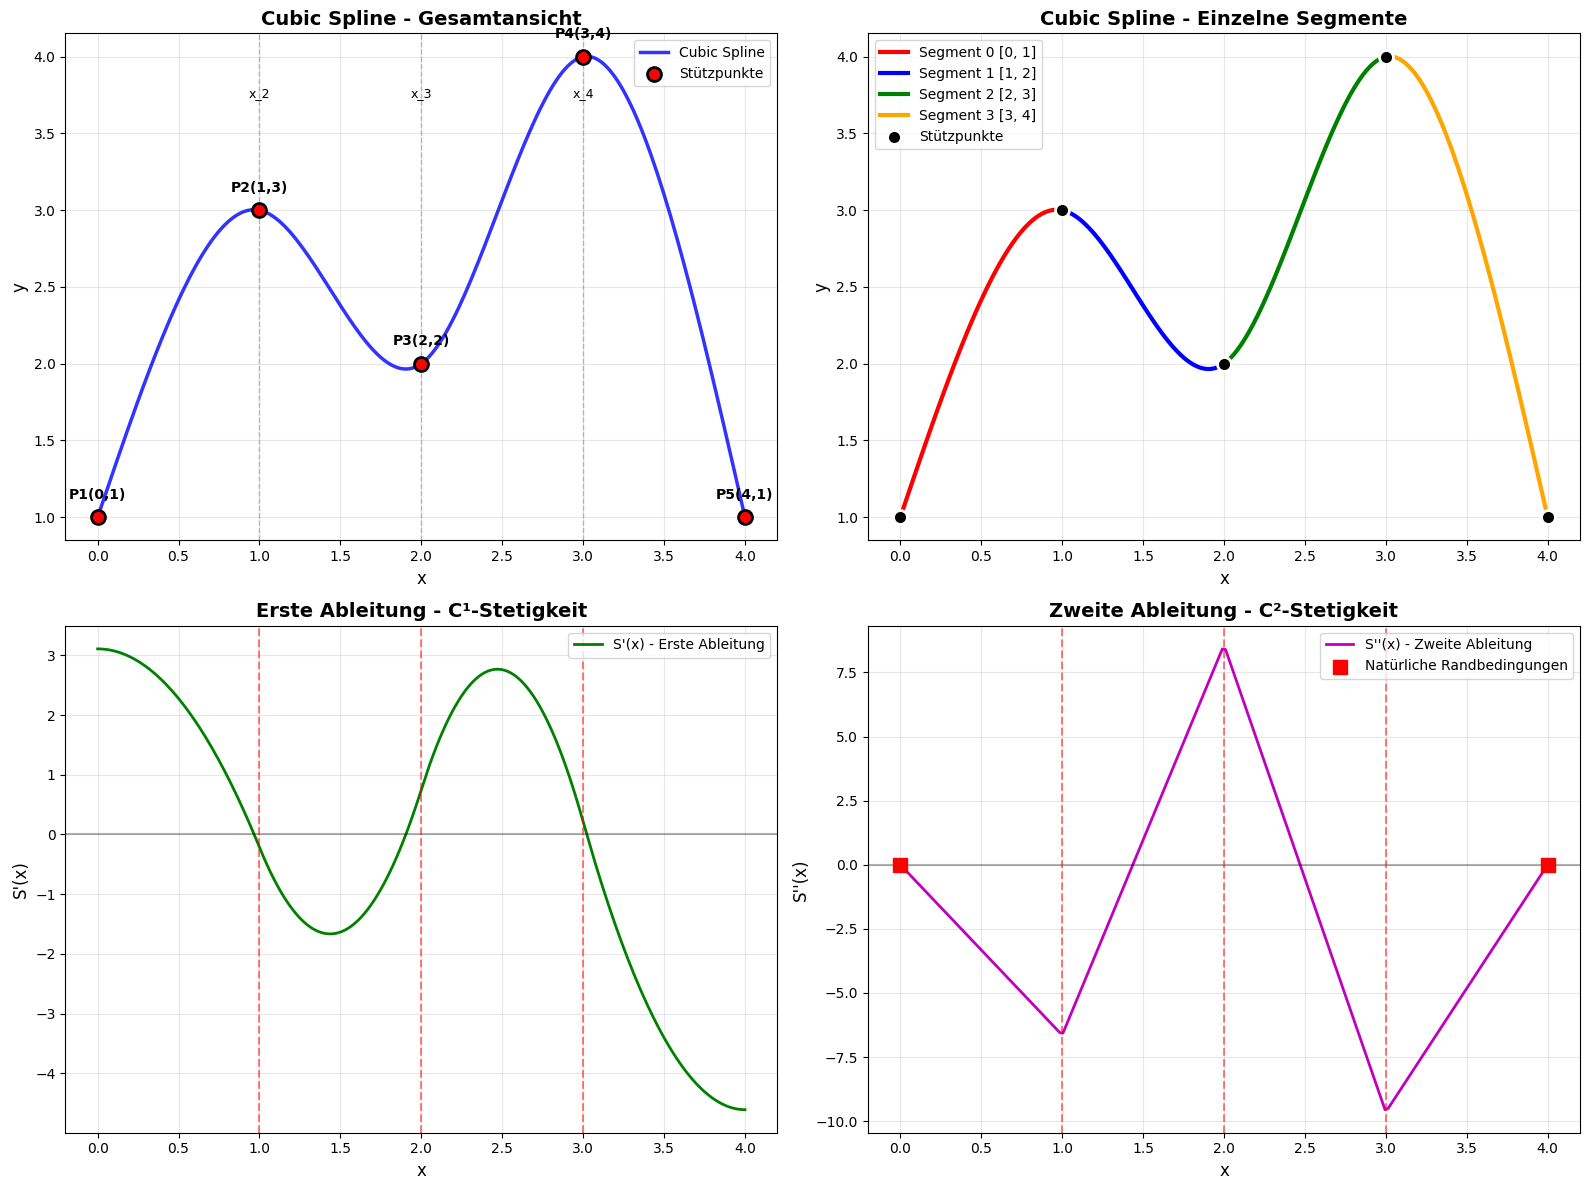


Eigenschaften der Lösung:
- Interpoliert 5 Stützpunkte
- Verwendet 4 kubische Segmente
- C⁰-stetig: Funktion ist stetig
- C¹-stetig: Erste Ableitung ist stetig
- C²-stetig: Zweite Ableitung ist stetig
- Natürliche Randbedingungen: S''(0) = S''(4) = 0


In [19]:
# SCHRITT 7: VISUALISIERUNG

# Erstelle feine x-Werte für glatten Spline
x_fine = np.linspace(spline_x[0], spline_x[-1], 200)
y_spline = [evaluate_spline(x, coeffs_full, spline_x, h) for x in x_fine]

# Erstelle die Hauptvisualisierung
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Gesamter Spline mit Stützpunkten
ax1.plot(x_fine, y_spline, 'b-', linewidth=2.5, label='Cubic Spline', alpha=0.8)
ax1.scatter(spline_x, spline_y, c='red', s=100, marker='o', 
           edgecolors='black', linewidths=2, label='Stützpunkte', zorder=5)

# Stützpunkte beschriften
for i, (x, y) in enumerate(zip(spline_x, spline_y)):
    ax1.text(x, y + 0.1, f'P{i+1}({x},{y})', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Intervall-Grenzen markieren
for i, x in enumerate(spline_x[1:-1], 1):
    ax1.axvline(x=x, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax1.text(x, ax1.get_ylim()[1]*0.9, f'x_{i+1}', ha='center', fontsize=9)

ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Cubic Spline - Gesamtansicht', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Einzelne Segmente färben
colors = ['red', 'blue', 'green', 'orange']
segment_names = ['Segment 0', 'Segment 1', 'Segment 2', 'Segment 3']

for i in range(4):  # 4 Intervalle
    # x-Werte für dieses Segment
    x_seg = np.linspace(spline_x[i], spline_x[i+1], 50)
    y_seg = [evaluate_spline(x, coeffs_full, spline_x, h) for x in x_seg]
    
    ax2.plot(x_seg, y_seg, color=colors[i], linewidth=3, 
            label=f'{segment_names[i]} [{spline_x[i]}, {spline_x[i+1]}]')

# Stützpunkte
ax2.scatter(spline_x, spline_y, c='black', s=100, marker='o', 
           edgecolors='white', linewidths=2, label='Stützpunkte', zorder=5)

ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Cubic Spline - Einzelne Segmente', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Erste Ableitung (Steigung)
x_deriv = np.linspace(spline_x[0], spline_x[-1], 200)
y_deriv = []

for x_val in x_deriv:
    # Bestimme Intervall
    i = 0
    for j in range(len(spline_x) - 1):
        if spline_x[j] <= x_val <= spline_x[j + 1]:
            i = j
            break
    
    # Erste Ableitung: S'_i(x) = b_i + 2*c_i*(x-x_i) + 3*d_i*(x-x_i)²
    b_i = coeffs_full[4*i + 1]
    c_i = coeffs_full[4*i + 2] 
    d_i = coeffs_full[4*i + 3]
    dx = x_val - spline_x[i]
    
    deriv = b_i + 2*c_i*dx + 3*d_i*dx**2
    y_deriv.append(deriv)

ax3.plot(x_deriv, y_deriv, 'g-', linewidth=2, label="S'(x) - Erste Ableitung")
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Knoten markieren wo C¹-Stetigkeit gilt
for x in spline_x[1:-1]:
    ax3.axvline(x=x, color='red', linestyle='--', alpha=0.5)

ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel("S'(x)", fontsize=12)
ax3.set_title('Erste Ableitung - C¹-Stetigkeit', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Zweite Ableitung (Krümmung)  
y_deriv2 = []

for x_val in x_deriv:
    # Bestimme Intervall
    i = 0
    for j in range(len(spline_x) - 1):
        if spline_x[j] <= x_val <= spline_x[j + 1]:
            i = j
            break
    
    # Zweite Ableitung: S''_i(x) = 2*c_i + 6*d_i*(x-x_i)
    c_i = coeffs_full[4*i + 2]
    d_i = coeffs_full[4*i + 3]
    dx = x_val - spline_x[i]
    
    deriv2 = 2*c_i + 6*d_i*dx
    y_deriv2.append(deriv2)

ax4.plot(x_deriv, y_deriv2, 'm-', linewidth=2, label="S''(x) - Zweite Ableitung")
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Randbedingungen markieren (natürlicher Spline: S''(0) = S''(4) = 0)
ax4.scatter([spline_x[0], spline_x[-1]], [0, 0], c='red', s=100, 
           marker='s', label='Natürliche Randbedingungen', zorder=5)

# Knoten markieren wo C²-Stetigkeit gilt
for x in spline_x[1:-1]:
    ax4.axvline(x=x, color='red', linestyle='--', alpha=0.5)

ax4.set_xlabel('x', fontsize=12)
ax4.set_ylabel("S''(x)", fontsize=12)
ax4.set_title('Zweite Ableitung - C²-Stetigkeit', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print("\nEigenschaften der Lösung:")
print(f"- Interpoliert {len(spline_x)} Stützpunkte")
print(f"- Verwendet {len(spline_x)-1} kubische Segmente")
print(f"- C⁰-stetig: Funktion ist stetig")
print(f"- C¹-stetig: Erste Ableitung ist stetig")
print(f"- C²-stetig: Zweite Ableitung ist stetig")
print(f"- Natürliche Randbedingungen: S''(0) = S''(4) = 0")